In [31]:
import pandas as pd

# 1. Load your financial data
# Replace 'financial_returns.csv' with your actual file path (CSV, Excel, etc.)
# We assume dates are in the first column and set them as the index

df = pd.read_csv('./data/concat_hf_data.csv', parse_dates=True).set_index('date')
df.index = pd.to_datetime(df.index)
df.drop(['bam'], axis=1, inplace=True)
df.head()

,maple_cap,arr,tidan,four_world,global_sigma,m1,vadantia,enko,cambrian,brummer
date,,,,,,,,,,
2002-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0168
2002-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0242
2002-06-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0451
2002-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0337
2002-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0104


In [32]:
df = df[df.index >= pd.to_datetime('2020-01-01')]

df.head()

,maple_cap,arr,tidan,four_world,global_sigma,m1,vadantia,enko,cambrian,brummer
date,,,,,,,,,,
2020-01-01,NaN,NaN,NaN,0.0215,0.0001,NaN,-0.0033,0.0237,0.204,0.0180
2020-02-01,NaN,NaN,NaN,-0.0206,0.0119,NaN,0.0185,0.0285,0.007,-0.0051
2020-03-01,-0.0200,NaN,NaN,-0.0342,0.0126,NaN,0.0262,0.0430,-0.036,-0.0446
2020-04-01,0.0272,NaN,NaN,0.0196,0.0115,NaN,-0.0433,0.0331,0.112,0.0001
2020-05-01,0.0004,NaN,NaN,0.0157,0.0085,NaN,-0.0039,0.0336,0.001,0.0581


In [33]:
ew_returns = df.mean(axis=1)

In [34]:
import yfinance as yf

# Download historical data
tickers = ['^SP500TR']
data = yf.download(tickers, start='2000-01-01', interval='1mo')

df = data['Close']

df.columns = ['SP500TR']

returns = df.pct_change().dropna()

returns

/var/folders/mc/qf75k40s6ns_nr8c35wdmp400000gn/T/ipykernel_10843/2180431824.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='2000-01-01', interval='1mo')
[*********************100%***********************]  1 of 1 completed


,SP500TR
Date,
2000-02-01,-0.018929
2000-03-01,0.097829
2000-04-01,-0.030086
2000-05-01,-0.020518
2000-06-01,0.024654
...,...
2026-01-01,0.014500
2026-02-01,-0.007600
2026-03-01,-0.049795


In [35]:
import pandas as pd

# Merge the two series side-by-side
merged_df = pd.concat([ew_returns, returns], axis=1).dropna()

# Optional: Rename the columns so they look clean
merged_df.columns = ['ew_returns', 'sp500']

merged_df

,ew_returns,sp500
2020-01-01,0.044000,-0.000392
2020-02-01,0.006700,-0.082319
2020-03-01,-0.007571,-0.123513
2020-04-01,0.022886,0.128194
2020-05-01,0.016200,0.047627
...,...,...
2025-12-01,0.003150,0.000612
2026-01-01,0.034856,0.014500
2026-02-01,0.008689,-0.007600
2026-03-01,-0.016878,-0.049795


In [36]:
merged_df.corr()

,ew_returns,sp500
ew_returns,1.00000,0.40842
sp500,0.40842,1.00000


In [37]:
import numpy as np

def calculate_portfolio_metrics(returns_series):
    """
    Calculates various portfolio performance metrics given a time series of monthly returns.

    Args:
        returns_series (pd.Series): A time series of monthly returns.

    Returns:
        dict: A dictionary containing the calculated metrics.
    """
    if returns_series.empty or returns_series.isnull().all():
        return {
            'CAGR': np.nan,
            'Standard Deviation': np.nan,
            'Mean Return': np.nan,
            'Max Drawdown': np.nan,
            'Winning Months (%)': np.nan,
            'Sharpe Ratio': np.nan,
            'Calmar Ratio': np.nan
        }

    # Drop NaN values for calculations, as empty check might not catch all cases
    returns_series = returns_series.dropna()
    if returns_series.empty:
        return {
            'CAGR': np.nan,
            'Standard Deviation': np.nan,
            'Mean Return': np.nan,
            'Max Drawdown': np.nan,
            'Winning Months (%)': np.nan,
            'Sharpe Ratio': np.nan,
            'Calmar Ratio': np.nan
        }

    # 1. Annualized Mean Return
    mean_return = returns_series.mean() * 12

    # 2. Annualized Standard Deviation
    std_dev = returns_series.std() * np.sqrt(12)

    # 3. CAGR (Compound Annual Growth Rate)
    total_growth = (1 + returns_series).prod()
    num_periods = len(returns_series)
    num_years = num_periods / 12.0
    cagr = (total_growth**(1/num_years)) - 1

    # 4. Max Drawdown
    cumulative_returns = (1 + returns_series).cumprod()
    peak = cumulative_returns.expanding(min_periods=1).max()
    drawdown = (cumulative_returns - peak) / peak
    max_drawdown = drawdown.min()

    # 5. Percentage of Winning Months
    winning_months = (returns_series > 0).sum()
    total_months = len(returns_series)
    percent_winning_months = (winning_months / total_months) * 100 if total_months > 0 else np.nan

    # 6. Sharpe Ratio (assuming risk-free rate is 0)
    sharpe_ratio = mean_return / std_dev if std_dev != 0 else np.nan

    # 7. Calmar Ratio
    calmar_ratio = cagr / abs(max_drawdown) if max_drawdown != 0 else np.nan

    metrics = {
        'CAGR': cagr,
        'Standard Deviation': std_dev,
        'Mean Return': mean_return,
        'Max Drawdown': max_drawdown,
        'Winning Months (%)': percent_winning_months,
        'Sharpe Ratio': sharpe_ratio,
        'Calmar Ratio': calmar_ratio
    }

    return metrics

In [38]:
calculate_portfolio_metrics(ew_returns)

{'CAGR': 0.18371902924817718,
 'Standard Deviation': 0.058829449609906714,
 'Mean Return': 0.1715245551378446,
 'Max Drawdown': -0.027313387774383975,
 'Winning Months (%)': 84.21052631578947,
 'Sharpe Ratio': 2.9156239991230573,
 'Calmar Ratio': 6.726336211595076}

In [39]:
import statsmodels.api as sm

# Recreate ew_ret using the mean of ALL return columns in the current merged_df.
# This will average 'brummer_ret', 'bam_ret', 'sp500_ret', and 'combined_strategy_ret'.
ew_ret_time_series = merged_df['ew_returns']

# Define the dependent variable (Y) and independent variable (X)
y = ew_ret_time_series.dropna()
X_raw = merged_df['sp500'].dropna()

# Align the series by index to ensure common periods for the regression
common_index = y.index.intersection(X_raw.index)
y_aligned = y.loc[common_index]
X_aligned = X_raw.loc[common_index]

# Add a constant to the independent variable (SP500 returns) for the intercept
X = sm.add_constant(X_aligned)

# Perform the Ordinary Least Squares (OLS) regression
model = sm.OLS(y_aligned, X)
results = model.fit()

# Print the regression summary, which includes coefficients, R-squared, and other statistics
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:             ew_returns   R-squared:                       0.167
Model:                            OLS   Adj. R-squared:                  0.156
Method:                 Least Squares   F-statistic:                     14.81
Date:                Wed, 20 May 2026   Prob (F-statistic):           0.000250
Time:                        19:09:54   Log-Likelihood:                 209.34
No. Observations:                  76   AIC:                            -414.7
Df Residuals:                      74   BIC:                            -410.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0125      0.002      6.735      0.0

<Axes: xlabel='date'>

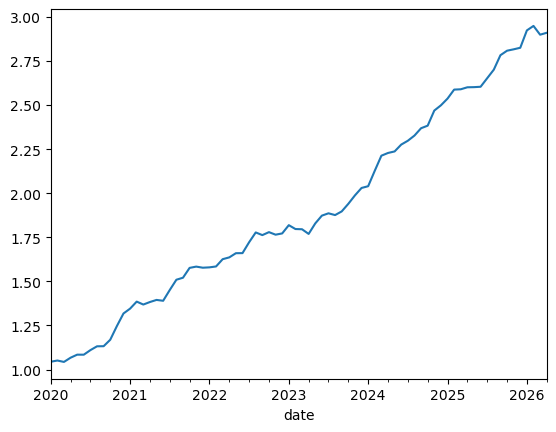

In [40]:
(1+ ew_returns).cumprod().plot()